## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**:


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

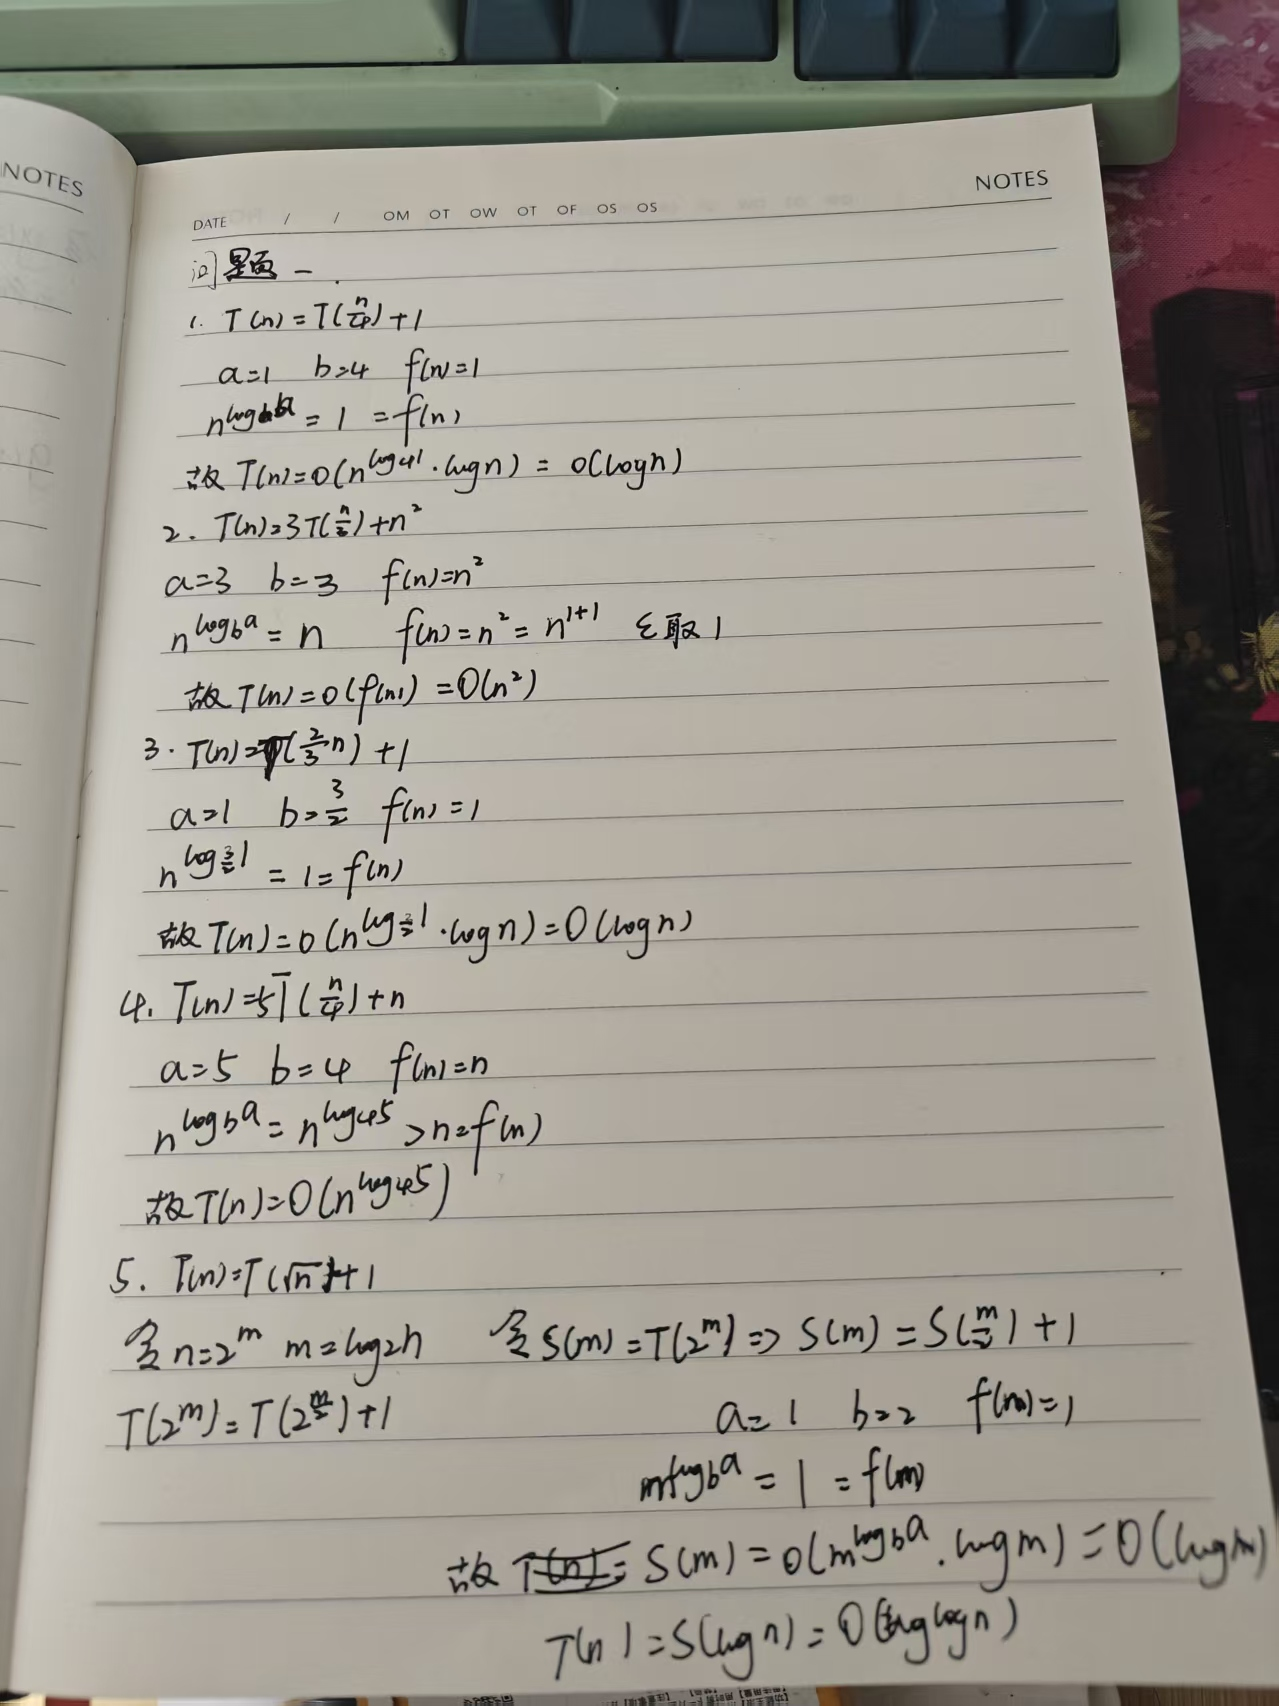

## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

idea:

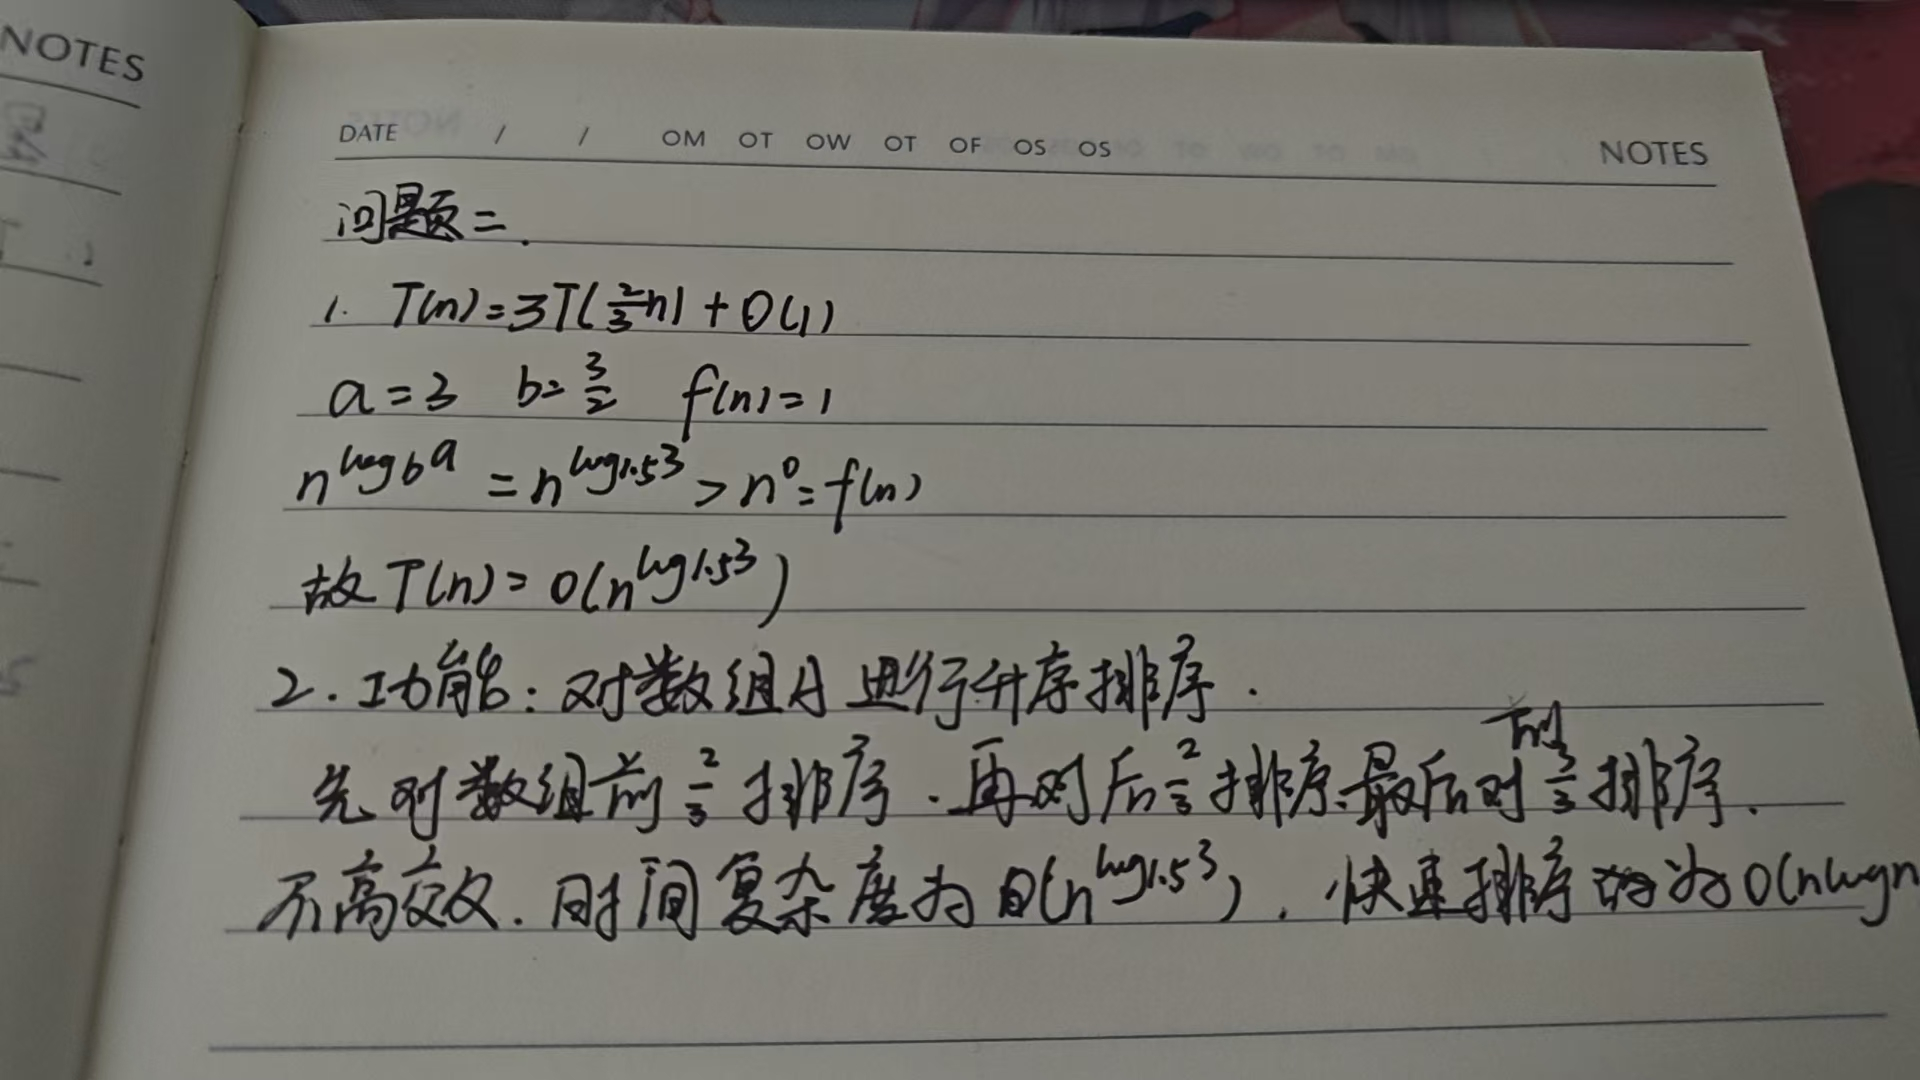

## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

idea:

In [ ]:
# 1. 核心解题思路:
#    题目给定的是股票每天的“净收益”（正数表示涨，负数表示跌）。在某一天买入并在未来的某一天卖出，
#    其最终获得的累计总收益，本质上就是这段连续日期内每日收益的“区间加总”。
#    因此，寻找最大利润的问题可以完美转化为经典算法中的【最大子数组和 (Maximum Subarray Sum)】问题。
#
# 2. 算法设计 :
#    本方案采用高效的 Kadane 算法。通过一次单向遍历，实时维护当前的累加收益 `current_sum`。
#    - 如果 `current_sum` 跌至负数，说明此前积累的收益对后续不仅没有帮助，反而会拖累后续的收益。
#      此时采取贪心策略，果断将计数清零，并把“潜在的买入起点”移动到当前位置。
#    - 如果 `current_sum` 保持为正，则继续向后累加。
#    - 在遍历的每一步中，用全局变量 `max_profit` 捕捉并更新历史最高总收益，同步锁定最佳的买卖区间。
#
# 3. 复杂度分析:
#    - 时间复杂度: O(n)。算法只需对包含 n 个元素的利润数组进行一次单重循环扫描，每个元素的处理时间均为 O(1)。
#    - 空间复杂度: O(1)。仅使用了常数个指针与变量来存储中间状态，未消耗任何与数据规模相关的额外空间。
# ==========================================

def find_max_profit(profits):
    if not profits:
        return 0, -1, -1

    # 初始化状态变量
    max_profit = float('-inf')  # 全局最高利润
    current_sum = 0             # 当前连续区间的收益累加值
    
    current_start = 0           # 探索中区间的起始索引
    best_buy_day = 0            # 锁定的最佳买入日期（前置点）
    best_sell_day = 0           # 锁定的最佳卖出日期

    for i in range(len(profits)):
        # 状态转移：若当前累积收益为负，则前面的区间无贡献，从当天重新建流
        if current_sum < 0:
            current_sum = profits[i]
            current_start = i
        else:
            current_sum += profits[i]

        # 动态更新全局最优解及对应的日期区间
        if current_sum > max_profit:
            max_profit = current_sum
            best_buy_day = current_start
            best_sell_day = i

    # 返回结果：max_profit为最大收益，
    # 含义为：在第 best_buy_day 天开盘前（或前一天收盘后）买入，在第 best_sell_day 天结束时卖出。
    return max_profit, best_buy_day, best_sell_day


# --- 验证与测试运行 ---
if __name__ == "__main__":
    profits_data = [3, 2, 1, -7, 5, 2, -1, 3, -1]
    max_p, buy_day, sell_day = find_max_profit(profits_data)

    print(f"最大利润: {max_p}")
    print(f"建议买入日期（开始获利）：第 {buy_day} 天")
    print(f"建议卖出日期（获利截止）：第 {sell_day} 天")

最大利润: 9
建议买入日期（开始获利）：第 4 天
建议卖出日期（获利截止）：第 7 天


最大利润: 9
建议买入日期（开始获利）：第 4 天
建议卖出日期（获利截止）：第 7 天

## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

idea:

In [ ]:
# 1. 核心解题思路:
#    题目给出了特殊的边界条件：A[1] > A[2] 且 A[n-1] < A[n]。这意味着数组的整体趋势是
#    开头向下滑动（递减），结尾向上滑升（递增）。因此，在数组内部必然至少存在一个局部最小值。
#    我们可以利用二分查找（Binary Search）的思想：对于任意的中间位置 mid：
#    - 如果 A[mid] 小于其左右邻居，则 A[mid] 本身就是一个局部最小值，直接返回。
#    - 如果 A[mid-1] < A[mid]，由于开头是递减的，说明在左半区间内必然存在一个转折点（即局部最小值），
#      此时可以将检索范围收缩至左半部分。
#    - 否则，说明右半区间必然存在转折点，将检索范围收缩至右半部分。
#
# 2. 复杂度分析 :
#    - 时间复杂度: O(log n)。每一步迭代都将当前的搜索空间减半，因此只需对数级的时间。
#    - 空间复杂度: O(1)。算法仅维护了三个位置指针，没有消耗额外的内存空间。
# ==============================================================================

def search_local_minimum(array):
    if not array:
        return None
    
    total_len = len(array)
    left_boundary = 0
    right_boundary = total_len - 1
    
    while left_boundary <= right_boundary:
        middle_idx = (left_boundary + right_boundary) // 2
        
        # 边界安全保护：若越界则赋予无穷大，确保边界对比逻辑正确
        left_neighbor = array[middle_idx - 1] if middle_idx > 0 else float('inf')
        right_neighbor = array[middle_idx + 1] if middle_idx < total_len - 1 else float('inf')
        
        # 检查是否达成局部最小值的定义
        if array[middle_idx] < left_neighbor and array[middle_idx] < right_neighbor:
            return array[middle_idx]
        
        # 处于上升沿，左侧必有局部最小值
        elif middle_idx > 0 and array[middle_idx - 1] < array[middle_idx]:
            right_boundary = middle_idx - 1
            
        # 处于下降沿或平地，右侧必有局部最小值
        else:
            left_boundary = middle_idx + 1
            
    return None

# 测试运行
sample_arr = [9, 3, 7, 2, 1, 4, 5]
found_val = search_local_minimum(sample_arr)
print(f"找到的局部最小值为: {found_val}")

找到的局部最小值为: 1


找到的局部最小值为: 1

## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

idea:

In [ ]:
# 1. 核心解题思路:
#    本题要求寻找数组中前 k 个最小的数，提供了不同的视角与约束条件：
#    - 方法一（全排序法）：将整个数组直接进行升序排列，然后切片取前 k 个元素。
#    - 方法二（常规小顶堆法）：通过逐个 push 构建一个小顶堆，然后执行 k 次弹出操作。
#    - 方法三（海量数据流式法 - 对应题 3*）：当数据总量巨大无法一次性载入内存，但内存可以容纳 k 个数据时，
#      我们建立一个大小固定为 k 的【大顶堆】。遍历数据流时，如果当前数小于堆顶，说明堆顶不是最小的前 k 个，
#      于是弹出堆顶并压入当前数。遍历结束后，大顶堆里的 k 个数就是最小的前 k 个数。
#
# 2. 复杂度分析:
#    - 方法一: 时间 O(n log n)，空间 O(n)（取决于排序实现）。
#    - 方法二: 连续 push 构堆时间为 O(n log n)，k 次 pop 时间为 O(k log n)。总时间 O(n log n)，空间 O(n)。
#    - 方法三: 维护一个大小为 k 的堆，每次调整时间为 O(log k)，遍历 n 个元素总时间 O(n log k)；
#             空间复杂度仅为 O(k)，极其适合海量外部存储数据的过滤。
# ==============================================================================

import heapq

# 1：全排序切片法
def get_k_by_sorting(numbers, k_elements):
    # 时间复杂度: O(n log n)
    return sorted(numbers)[:k_elements]


# 2：逐个插入小顶堆法
def get_k_by_basic_heap(numbers, k_elements):
    # 时间复杂度: O(n log n)
    min_heap = []
    for element in numbers:
        heapq.heappush(min_heap, element)
        
    extracted_items = []
    for _ in range(k_elements):
        if min_heap:
            extracted_items.append(heapq.heappop(min_heap))
    return extracted_items


# 3*：应对超大文件的固定容量大顶堆法
def get_k_by_bounded_max_heap(numbers_stream, k_elements):
    # 时间复杂度: O(n log k)，空间复杂度: O(k)
    # Python 的 heapq 默认是小顶堆，存入负值即可模拟大顶堆
    max_heap = []
    
    for element in numbers_stream:
        if len(max_heap) < k_elements:
            heapq.heappush(max_heap, -element)
        else:
            # 如果当前元素比大顶堆的堆顶还要小，则替换堆顶
            if element < -max_heap[0]:
                heapq.heappushpop(max_heap, -element)
                
    # 恢复正数并升序排列输出
    return sorted([-x for x in max_heap])

# 测试运行
data_source = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
target_k = 3
print(f"排序法结果: {get_k_by_sorting(data_source, target_k)}")
print(f"基础堆结果: {get_k_by_basic_heap(data_source, target_k)}")
print(f"大顶堆流式法结果: {get_k_by_bounded_max_heap(data_source, target_k)}")

排序法结果: [1, 2, 3]
基础堆结果: [1, 2, 3]
大顶堆流式法结果: [1, 2, 3]


排序法结果: [1, 2, 3]
基础堆结果: [1, 2, 3]
大顶堆流式法结果: [1, 2, 3]

## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

In [5]:
# 1. 核心解题思路:
#    星球在同一直线上运动，正数向右，负数向左。只有当“栈中已有的向右运动的星球”遇到
#    “当前向左运动的星球”时，才会发生碰撞。这符合后进先出（LIFO）的特征，因此采用栈（Stack）来模拟。
#    - 遍历每一个星球 `planet`，如果它向右移动 (`planet > 0`)，直接安全入栈。
#    - 如果它向左移动 (`planet < 0`)，则需要连续检查栈顶是否有向右移动的星球：
#      a) 若栈顶质量小于当前星球，则栈顶星球爆炸被销毁（`pop`），继续与新的栈顶碰撞。
#      b) 若栈顶质量大于当前星球，当前星球爆炸，停止碰撞连锁。
#      c) 若两星球质量相同，双双湮灭（栈顶弹出，当前星球标记为销毁，停止连锁）。
#
# 2. 复杂度分析 :
#    - 时间复杂度: O(n)。虽然内部有一个 `while` 循环，但每个星球最多被压入栈一次，弹出栈一次。
#    - 空间复杂度: O(n)。最坏情况下（全向右或全向左），栈需要存储所有星球。
# ==============================================================================

def execute_planet_simulation(planets):
    survived_stack = []
    
    for current_planet in planets:
        is_active = True
        
        # 触发碰撞机制：当前星球向左 (<0) 且先前有向右的星球 (>0) 驻留栈顶
        while survived_stack and current_planet < 0 and survived_stack[-1] > 0:
            top_planet_mass = survived_stack[-1]
            current_planet_mass = abs(current_planet)
            
            if top_planet_mass < current_planet_mass:
                survived_stack.pop()  # 栈顶被撞碎，继续循环
                continue
            elif top_planet_mass == current_planet_mass:
                survived_stack.pop()  # 双方同归于尽
                is_active = False
                break
            else:
                is_active = False     # 当前星球被栈顶撞碎
                break
                
        if is_active:
            survived_stack.append(current_planet)
            
    return survived_stack

# 测试验证
case_1 = [-3, -6, 2, 8, 5, -8, 9, -2, 1]
case_2 = [23, -8, 9, -3, -7, 9, -23, 22]
print(f"测试 1 输出: {execute_planet_simulation(case_1)}")
print(f"测试 2 输出: {execute_planet_simulation(case_2)}")

测试 1 输出: [-3, -6, 2, 9, 1]
测试 2 输出: [22]


测试 1 输出: [-3, -6, 2, 9, 1]
测试 2 输出: [22]

## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [6]:
# 1. 核心解题思路:
#    本题是经典的 0-1 背包问题（每件大理石只能选 0 次或 1 次）。我们使用动态规划（DP）求解。
#    为了节省空间，我们采用一维滚动数组 `dp[w]`，其中 `dp[w]` 表示在小推车承重上限为 w 时能获得的最大价值。
#    - 核心状态转移方程为：dp[w] = max(dp[w], dp[w - weight] + value)
#    - 关键细节：一维背包在更新容量时，必须采取【从大到小逆序遍历】的策略。这样可以确保
#      更新 `dp[w]` 时所依赖的 `dp[w - weight]` 依然保存的是“尚未放入当前大理石”的前一轮历史状态，
#      从而严格限制了每块大理石只能被挑选一次。
#
# 2. 复杂度分析 :
#    - 时间复杂度: O(n * W)，其中 n 是大理石的数量（4块），W 是小推车的最大承重（9）。
#    - 空间复杂度: O(W)，只需要一个长度为承重上限 + 1 的一维数组。
# ==============================================================================

def solve_marbles_knapsack(items_list, max_capacity):
    # 初始化状态转移表
    dp_table = [0] * (max_capacity + 1)
    
    # 逐一考察每块大理石
    for item_weight, item_value in items_list:
        # 逆序遍历容量，防止同一物品被重复叠加
        for current_cap in range(max_capacity, item_weight - 1, -1):
            dp_table[current_cap] = max(
                dp_table[current_cap], 
                dp_table[current_cap - item_weight] + item_value
            )
            
    return dp_table[max_capacity]

# 输入大理石数据与容量约束
marbles_data = [(5, 10), (4, 40), (6, 30), (3, 50)]
cart_limit = 9

result_value = solve_marbles_knapsack(marbles_data, cart_limit)
print(f"小推车能装载的大理石最大价值为: {result_value}")

小推车能装载的大理石最大价值为: 90


小推车能装载的大理石最大价值为: 90

## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

idea:

In [8]:
# 1. 核心解题思路:
#    符合规范的二叉搜索树（BST）在进行【中序遍历】时，得到的节点值序列应当是严格单调递增的。
#    如果其中有两个节点的值被错误地交换了，其中序遍历的单调递增性质就会被打破，产生“逆序对”。
#    例如，正确序列为 [1, 2, 3, 4, 5]。若 2 和 5 被错误交换，序列变成 [1, 5, 3, 4, 2]。
#    在这个错误的序列中，我们会发现两处异常（逆序对）：
#    - 第一处异常：5 -> 3（前驱大于后继），此时错误的根源在于高位变大了，所以“第一个错误节点”是 5。
#    - 第二处异常：4 -> 2（前驱大于后继），此时错误的根源在于低位变小了，所以“第二个错误节点”是 2。
#    特殊情况：如果被交换的两个节点在序列中原本就是相邻的（如交换 2 和 3 变成 [1, 3, 2, 4, 5]），
#    则只会产生一处异常（3 -> 2）。此时第一个错误节点为 3，第二个错误节点为 2。
#
# 2. 算法设计:
#    本方案采用隐式深度优先的中序遍历。利用全局指针 `self.previous_node` 记录上一个刚访问过的节点。
#    在遍历过程中，一旦发现 `self.previous_node.val > current_node.val`，即触发错误拦截：
#    - 如果 `self.first_error` 尚未赋值，说明遇到了第一个逆序对，将 `self.first_error` 指向较前驱的节点。
#    - 无论是不是第一次遇到，都将 `self.second_error` 指向当前的较小节点（这能完美兼顾相邻和不相邻的两种情况）。
#    遍历结束后，直接交换这两个指针所指向的节点数值，完成树结构的物理修复。
#
# 3. 复杂度分析 :
#    - 时间复杂度: O(N)。算法需要对整棵树的 N 个节点进行一次完整的中序深度扫描。
#    - 空间复杂度: O(H)。其中 H 为二叉树的高度。这代表了递归搜索时系统分配的函数调用栈深度。
# ==============================================================================

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class BstRestorer:
    def recoverTree(self, root: TreeNode) -> None:
        # 初始化用于锁定错误节点的核心指针
        self.first_error = None
        self.second_error = None
        self.previous_node = None
        
        def traverse_inorder(current_node):
            if not current_node:
                return
            
            # 1. 递归步进左子树
            traverse_inorder(current_node.left)
            
            # 2. 核心业务：校验中序遍历的单调性
            if self.previous_node and self.previous_node.val > current_node.val:
                # 首次遇到逆序对，锁定第一个错误节点（值偏大的前驱）
                if not self.first_error:
                    self.first_error = self.previous_node
                # 持续更新第二个错误节点（值偏小的后继）
                self.second_error = current_node
            
            # 移动滑窗前驱指针
            self.previous_node = current_node
            
            # 3. 递归步进右子树
            traverse_inorder(current_node.right)
            
        # 激活中序遍历流
        traverse_inorder(root)
        
        # 物理交换两个被错置的节点值
        if self.first_error and self.second_error:
            self.first_error.val, self.second_error.val = self.second_error.val, self.first_error.val


# ==============================================================================
# 工具函数及验证用例
# ==============================================================================
def deserialize_list_to_tree(flat_list):
    if not flat_list: 
        return None
    tree_root = TreeNode(flat_list[0])
    node_queue = [tree_root]
    list_idx = 1
    while node_queue and list_idx < len(flat_list):
        parent_node = node_queue.pop(0)
        if list_idx < len(flat_list) and flat_list[list_idx] is not None:
            parent_node.left = TreeNode(flat_list[list_idx])
            node_queue.append(parent_node.left)
        list_idx += 1
        if list_idx < len(flat_list) and flat_list[list_idx] is not None:
            parent_node.right = TreeNode(flat_list[list_idx])
            node_queue.append(parent_node.right)
        list_idx += 1
    return tree_root

def serialize_tree_to_list(tree_root):
    if not tree_root: 
        return []
    output_list, node_queue = [], [tree_root]
    while node_queue:
        current = node_queue.pop(0)
        if current:
            output_list.append(current.val)
            node_queue.append(current.left)
            node_queue.append(current.right)
        else:
            output_list.append(None)
    while output_list and output_list[-1] is None: 
        output_list.pop()
    return output_list


# --- 测试用例跑通 ---
if __name__ == "__main__":
    restorer = BstRestorer()

    # 测试样例 1
    case1_root = deserialize_list_to_tree([1, 3, None, None, 2])
    restorer.recoverTree(case1_root)
    print(f"示例 1 输出: {serialize_tree_to_list(case1_root)}") 

    # 测试样例 2
    case2_root = deserialize_list_to_tree([3, 1, 4, None, None, 2])
    restorer.recoverTree(case2_root)
    print(f"示例 2 输出: {serialize_tree_to_list(case2_root)}")

示例 1 输出: [3, 1, None, None, 2]
示例 2 输出: [2, 1, 4, None, None, 3]


示例 1 输出: [3, 1, None, None, 2]
示例 2 输出: [2, 1, 4, None, None, 3]

## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [ ]:
# add your code here
# your algorithm time complexity is:

## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

idea:

In [10]:
# 1. 核心解题思路:
#    本题的目标是求出二叉树中所有“根节点到叶子节点”路径所表示的数字之和。
#    每一条完整的路径（从根到叶子）对应一个十进制数。为了高效解决这个问题，采用
#    【深度优先搜索 (DFS)】是最自然且高效的方法。
#    - 状态传递与高位左移：在向下递归时，必须维持并传递一个当前路径已经累加出的数字。
#      每当从父节点移向子节点，由于数字多了一位（高位需要向左移动），我们将之前的累加值
#      乘以 10，然后加上当前节点的值，即：current_sum = prev_sum * 10 + node.val。
#    - 叶子节点判定：一旦遇到某个节点的左右子树都为空（即没有子节点），说明一条完整的
#      数字路径已经走完，此时直接返回计算出来的 `current_sum`。
#    - 非叶子节点汇总：若当前节点不是叶子节点，则分别对它的左子树和右子树进行递归调用，
#      最后将左子树产生的所有路径和与右子树产生的路径和进行相加汇总（+），并向上返回。
#
# 2. 复杂度分析 :
#    - 时间复杂度: O(N)，其中 N 是二叉树中的节点总数。DFS 遍历会且仅会访问每个节点一次，
#      每个节点的处理（乘 10 和加法）在 O(1) 时间内完成。
#    - 空间复杂度: O(H)，其中 H 是二叉树的高度。在最坏情况下（树退化为一条链表时，H = N），
#      系统隐式开辟的递归调用栈深度将达到最大值 H。
# ==============================================================================

# add your code here
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def sumNumbers(self, root: TreeNode) -> int:
        def dfs(node, prev_sum):
            if not node:
                return 0
            
            # 位数迭代更新：将高位结果乘以 10 腾出个位，再融入当前节点的值
            current_sum = prev_sum * 10 + node.val
            
            # 如果是叶子节点，返回当前数字
            if not node.left and not node.right:
                return current_sum
            
            # 如果不是叶子节点，递归左右子树并求和
            return dfs(node.left, current_sum) + dfs(node.right, current_sum)
        
        return dfs(root, 0)

def build_tree_from_list(nodes):
    if not nodes: return None
    root = TreeNode(nodes[0])
    queue = [root]
    i = 1
    while queue and i < len(nodes):
        curr = queue.pop(0)
        if i < len(nodes) and nodes[i] is not None:
            curr.left = TreeNode(nodes[i])
            queue.append(curr.left)
        i += 1
        if i < len(nodes) and nodes[i] is not None:
            curr.right = TreeNode(nodes[i])
            queue.append(curr.right)
        i += 1
    return root

# --- 测试数据运行 ---
root1 = build_tree_from_list([1, 2, 3])
sol = Solution()
print(f"示例 1 输入 [1,2,3], 输出结果: {sol.sumNumbers(root1)}") # 预期 25

root2 = build_tree_from_list([4, 9, 0, 5, 1])
print(f"示例 2 输入 [4,9,0,5,1], 输出结果: {sol.sumNumbers(root2)}") # 预期 1026

# your algorithm time complexity is: O(N)

示例 1 输入 [1,2,3], 输出结果: 25
示例 2 输入 [4,9,0,5,1], 输出结果: 1026


示例 1 输入 [1,2,3], 输出结果: 25
示例 2 输入 [4,9,0,5,1], 输出结果: 1026